## Modelo de Regresión

In [9]:
from models.Modelo_Regresion import ModeloRegresion, modelo

X, y, X_train, X_test, y_train, y_test = modelo.entrena_prueba(modelo.df)

Resultado de X_train.shape (5625, 13)
Resultado de y_test.shape (7032,)


## Escalado

In [10]:
modelo.escalado(X_train, X_test) # Escala y guarda en modelo.X_train / modelo.X_test

Escalado de X_train.shape (5625, 13)
Escalado de X_test.shape (1407, 13)


## Creación del Modelo Regresión

Epoch 1/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1569 - val_loss: 0.1444
Epoch 2/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1456 - val_loss: 0.1425
Epoch 3/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1430 - val_loss: 0.1409
Epoch 4/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1418 - val_loss: 0.1407
Epoch 5/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1417 - val_loss: 0.1401
Epoch 6/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1414 - val_loss: 0.1400
Epoch 7/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1409 - val_loss: 0.1398
Epoch 8/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1408 - val_loss: 0.1394
Epoch 9/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1405 - val_loss: 0.1403
Epoch 10/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1407 - val_loss: 0.1389
Epoch 11/600
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1402 - val_loss: 0.1398
Epoch 12/600
176/176 ━━━━━━━━━━━━━━━━━━━━

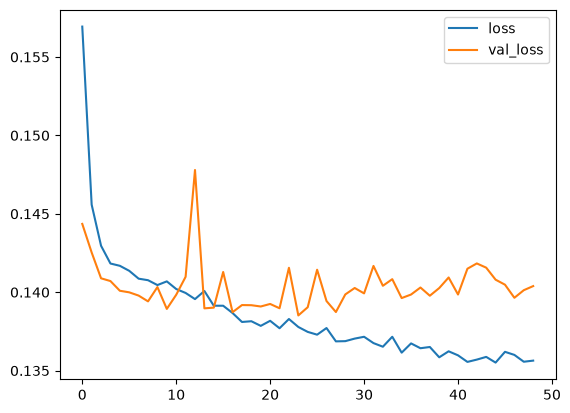

In [11]:
modelo.creacion_model(X, y, modelo.X_train, modelo.X_test, y_train, y_test) # Entrena con datos escalados

Como podemos observar en este gráfico, el modelo fue entrenado durante 49 épocas antes de que el Early Stopping detuviera el proceso automáticamente, ambas líneas, loss y val_loss, inician en valores 'altos' y descienden hasta los valores de 0.140 - 0.135, lo cual nos indica que el modelo aprendió bien. Un detalle es el pico que se observa en la época 12 en la línea naranja, lo cual representa un momento de inestabilidad en la validación.

## Métricas

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Error absoluto medio 0.264470636844635
Error cuadratico medio 0.374686070010755
Varianza 0.26186656951904297
Error absoluto medio 0.995054851948354


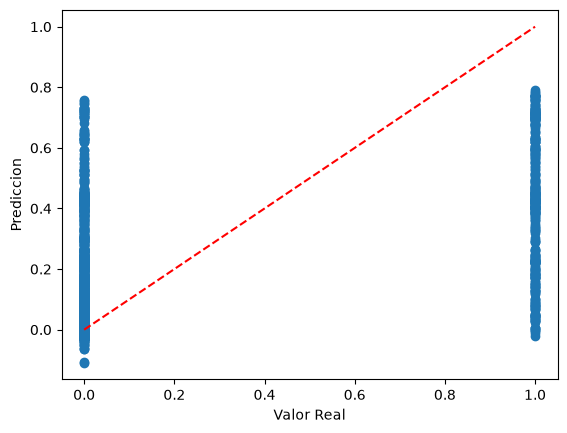

C:\Users\sharo\OneDrive\Documentos\Proyecto\models\Modelo_Regresion.py:125: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(errors)  # Idealmente debe estar concentrado el error en 0


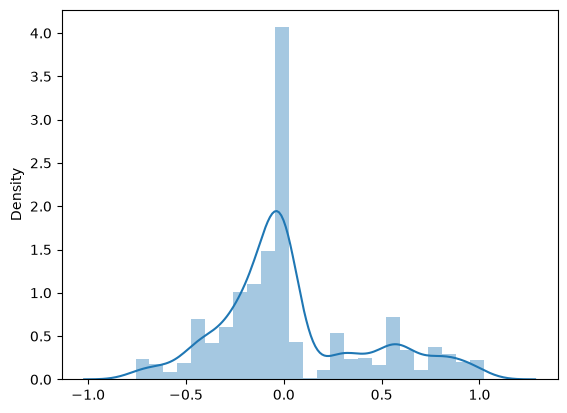

In [12]:
modelo.prediccion(modelo.X_test, y_test) # Métricas con datos escalados

**Interpretación 1° gráfico:** Como podemos observar, este gráfico nos muestra los puntos que se concentran unicamente en los extremos 0 y 1, lo cual si lo esperabamos ya que, Churn es una variable binaria, la línea roja nos presenta la predicción perfecta, el modelo muestra un comportamiento razonable, pero, tenemos un desbalance, la columna del 0 tiene más puntos dispersos que la del 1, lo que indica que el modelo tiene más dificultad para identificar correctamente a los clientes que sí abandonan.

**Interpretación 2° gráfico:** Como podemos observar, este gráfico nos muestra que tan lejos estuvieron las predicciones del valor real, lo más ideal es que la mayor concentración de errores esté en 0, podriamos decir que si pasa en nuestro modelo, pero, se observa una cola hacia la derecha (errores positivos), lo que confirma que el modelo tiende a subestimar los casos de Churn, ósea, predice que un cliente no se va cuando en realidad sí lo hace

## Accurancy

In [13]:
modelo.prediccion_acc(modelo.X_test, y_test) # Accuracy con datos escalados

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1052
           1       0.66      0.34      0.45       355

    accuracy                           0.79      1407
   macro avg       0.74      0.64      0.66      1407
weighted avg       0.77      0.79      0.76      1407

[[990  62]
 [233 122]]


 Con respecto a estas metricas tenemos que, la clase 0 (no abandonan) el modelo alcanza un rendimiento del 94%, mientras que para la clase 1 (abandonan) solo llega al 34%, la precisión de nuestro modelo es del 79%, pero este número puede llegar a ser engañoso porque está lleno por la clase mayoritaria (0), y la matriz de confusión nos muestra que de 990 clientes que realmente abandonaron, el modelo solo identificó correctamente 122, fallando en 233 casos.

## Nivel de Riesgo

In [14]:
resultados = modelo.predecir_riesgo(modelo.X_test) # Riesgo con datos escalados
print(resultados.head(10))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Distribución por nivel de riesgo:
nivel_riesgo
Bajo riesgo     1056
Medio riesgo     274
Alto riesgo       77
Name: count, dtype: int64
   risk_score  nivel_riesgo
0    0.489019  Medio riesgo
1    0.148390   Bajo riesgo
2    0.197132   Bajo riesgo
3    0.649937  Medio riesgo
4    0.077447   Bajo riesgo
5   -0.026589   Bajo riesgo
6    0.460053  Medio riesgo
7   -0.014832   Bajo riesgo
8    0.716489   Alto riesgo
9    0.408315  Medio riesgo
